# Examine ALE Plots 

- Observation: The ALE curve for $x_2$ for $f(x) = x_1 + x_1  x_2$ looks like a quadratic when $x_1,x_2$ are highly correlated.
    - No, rather we might expect it as the "average" in the dataset of $x_2$ as $x_3$ varies, that is, the ALE curve $f_{ALE,j}(x_2)=\mathbb{E}[X_1\mid X_2=x_2]x_2$. Since we can roughly estimate $\mathbb{E}[X_1\mid X_2=x_2]=x_2$ due to the high correlation, we would expect to see a quadratic curve.
    - This is the *correct inference*, as we should expect that as $x_2$ increases, the value of $f$ should increase due to both $x_2$ getting larger, and $x_1$ getting larger *because it tends to be larger with $x_2$.

- Observation: It seems like the main effects are somehow also capturing some interaction effects. For example, with highly correlated $X_1,X_2$, we have $f(x)=x_1+x_2+x_1x_2$ producing $ALE_{j,M}\approx ALE^Q_{j,T}$. Now that we observe the above example, this makes sense -- the ALE plot takes into account the interaction behavior and therefore the main effect does too.

- Observation: The VIM changes as the number of bins varies.

In [182]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# from algorithms.fast_ale import (
#     ale_1d_fast as ale_1d,
#     ale_2d_fast as ale_2d,
#     ale_global_main_fast as ale_global_main,
#     ale_connected_total_fast as ale_connected_total,
#     ale_connected_modified_total_fast as ale_connected_modified_total,
#     ale_quantile_total_fast as ale_quantile_total
# )

from algorithms.ale import (
    ale_1d,
    ale_2d,
    bin_selection,
    reorder_categories
)
from algorithms.ale_vim import (
    ale_global_main,
    ale_connected_total,
    ale_connected_modified_total,
    ale_quantile_total
)

In [183]:
# generate data
def generate_2d_data(n, sigma=0.05):
    Z = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    epsilon = np.random.normal(0, sigma, n)
    X1 = Z
    X2 = Z + epsilon

    return np.vstack([X1, X2]).T

def generate_2d_data_normal(n, rho=0.5):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_3d_data(n, sigma=0.05):
    Z = np.random.uniform(1, 2, n)
    epsilon_1 = np.random.normal(0, sigma, n)
    epsilon_2 = np.random.normal(0, sigma, n)
    epsilon_3 = np.random.normal(0, sigma, n)
    X1 = Z + epsilon_1
    X2 = Z + epsilon_2
    X3 = Z + epsilon_3
    return np.vstack([X1, X2, X3]).T

def generate_mixed_data(n, num_categories=3):
    x1 = np.random.randint(0, num_categories, n)
    x2 = np.random.uniform(0, 1, n)
    return np.vstack([x1, x2]).T

In [184]:
def replicate_ale_global_main(dgp, f, n, bins=20, replications=100, stabilize=False):
    """Replicate ALE variable importance."""
    vim_1_mains = []
    vim_2_mains = []
    vim_1_totals = []
    vim_2_totals = []
    vim_1_quantiles = []
    vim_2_quantiles = []
    for i in range(replications):
        X = dgp(n)
        edges1, curve1 = ale_1d(f, X, 1, bins=bins)
        edges2, curve2 = ale_1d(f, X, 2, bins=bins)
        vim_1_main = ale_global_main(edges1, curve1, X, 1, stabilize=stabilize)
        vim_2_main = ale_global_main(edges2, curve2, X, 2, stabilize=stabilize)
        vim_1_mains.append(vim_1_main)
        vim_2_mains.append(vim_2_main)
        vim_1_total = ale_connected_total(f, X, 1, bins=bins)
        vim_2_total = ale_connected_total(f, X, 2, bins=bins)
        vim_1_totals.append(vim_1_total)
        vim_2_totals.append(vim_2_total)
        vim_1_quantile = ale_quantile_total(f, X, 1, bins=bins)
        vim_2_quantile = ale_quantile_total(f, X, 2, bins=bins)
        vim_1_quantiles.append(vim_1_quantile)
        vim_2_quantiles.append(vim_2_quantile)
        print(f"Replication {i + 1}: VIM 1 Main: {vim_1_main}, VIM 2 Main: {vim_2_main}, "
              f"VIM 1 Connected: {vim_1_total}, VIM 2 Connected: {vim_2_total}, "
              f"VIM 1 Quantile: {vim_1_quantile}, VIM 2 Quantile: {vim_2_quantile}", sep="\n")

    print("VIM 1 Main Importance - Mean:", np.mean(vim_1_mains), "CI:", np.percentile(vim_1_mains, [2.5, 97.5]))
    print("VIM 2 Main Importance - Mean:", np.mean(vim_2_mains), "CI:", np.percentile(vim_2_mains, [2.5, 97.5]))
    print("VIM 1 Total Importance - Mean:", np.mean(vim_1_totals), "CI:", np.percentile(vim_1_totals, [2.5, 97.5]))
    print("VIM 2 Total Importance - Mean:", np.mean(vim_2_totals), "CI:", np.percentile(vim_2_totals, [2.5, 97.5]))
    print("VIM 1 Quantile Importance - Mean:", np.mean(vim_1_quantiles), "CI:", np.percentile(vim_1_quantiles, [2.5, 97.5]))
    print("VIM 2 Quantile Importance - Mean:", np.mean(vim_2_quantiles), "CI:", np.percentile(vim_2_quantiles, [2.5, 97.5]))

    return vim_1_mains, vim_2_mains, vim_1_totals, vim_2_totals


In [185]:
# Setting 1: normal DGP
# def f(x):
#     return x[0] + x[1] + x[0] * x[1]
# n = 2500
# rho = 0.5
# bins = 250 # bin_selection(n)
# dgp = lambda n: generate_2d_data_normal(n, rho=rho)

# Setting 2: uniform DGP
# def f(x):
#     return x[0] + x[1] + x[0] * x[1]
# n = 2500
# sigma = 0.2
# bins = bin_selection(n)
# dgp = lambda n: generate_2d_data(n, sigma=sigma)

# Setting 3: mixed categorical and continuous DGP
def f(x):
    return x[:, 0] + x[:, 1] + x[:, 0] * x[:, 1] 
n = 1600
bins = bin_selection(n)
dgp = lambda n: generate_mixed_data(n, num_categories=4)

X = dgp(n)
y = f(X)

In [186]:
# rhos = np.linspace(0.1, 1, 10)
# var_list = []
# theory_list = []
# for rho in rhos:
#     m = 1000000
#     gamma = norm.rvs(loc=0, scale=np.sqrt(1 - rho**2), size=m)
#     x1 = norm.rvs(loc=0, scale=1, size=m)
#     var_list.append(np.var((1 + gamma) * x1 + (1 / 2) * rho * x1 ** 2))
#     theory_list.append(2 - (1 / 2) * rho**2)

# # plot
# plt.plot(rhos, var_list, marker='o', label='Empirical')
# plt.plot(rhos, theory_list, marker='x', label='Theoretical')
# plt.xlabel('Correlation (rho)')
# plt.ylabel('Variance')
# plt.title('Variance vs Correlation')
# plt.legend()
# plt.grid()
# plt.show()

In [187]:
# vim_1_mains, vim_2_mains, vim_1_totals, vim_2_totals = replicate_ale_global_main(dgp, f, n=n, bins=bins, replications=10, stabilize=True)

In [188]:
# # plot heatmap of vim_1_mains and vim_2_mains
# plt.figure(figsize=(10, 5))
# plt.hist2d(vim_1_mains, vim_2_mains, bins=20, cmap='Blues')
# plt.colorbar(label='Frequency')
# plt.xlabel('VIM 1 Main Importance')
# plt.ylabel('VIM 2 Main Importance')
# plt.title('Heatmap of VIM 1 and VIM 2 Main Importance')
# plt.show()

In [189]:
# # plot heatmap of vim_1_totals and vim_2_totals
# plt.figure(figsize=(10, 5))
# plt.hist2d(vim_1_totals, vim_2_totals, bins=20, cmap='Blues')
# plt.colorbar(label='Frequency')
# plt.xlabel('VIM 1 Total Importance')
# plt.ylabel('VIM 2 Total Importance')
# plt.title('Heatmap of VIM 1 and VIM 2 Total Importance')
# plt.show()

In [190]:
# vim_1_modified_total = ale_connected_modified_total(f, X, 1, bins=bins)
# vim_2_modified_total = ale_connected_modified_total(f, X, 2, bins=bins)
# print(f"X1 Total Modified Connected Importance: {round(vim_1_modified_total, 3)}, X2 Total Modified Connected Importance: {round(vim_2_modified_total, 3)}")

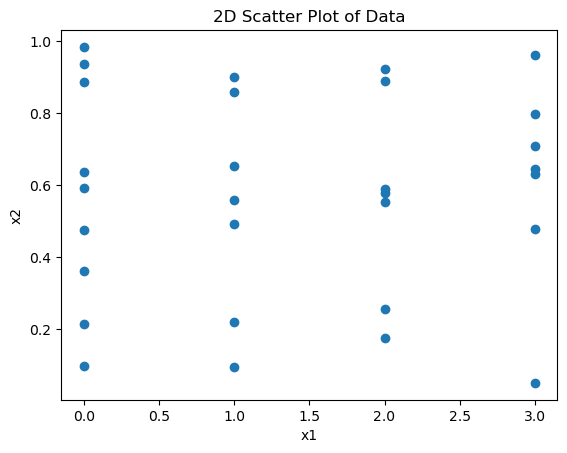

In [ ]:
# 2d scatter plot
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Scatter Plot of Data")
plt.show()

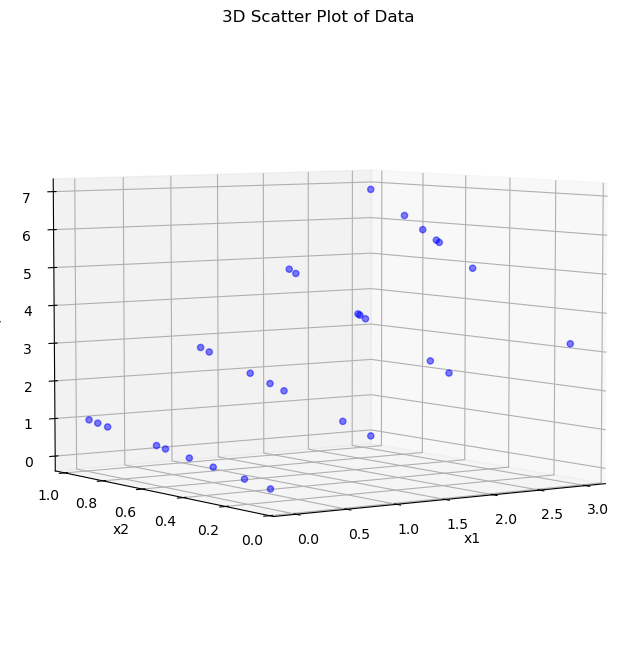

In [ ]:
# 3d scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(5, 235)
ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', alpha=0.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Scatter Plot of Data')
plt.show()

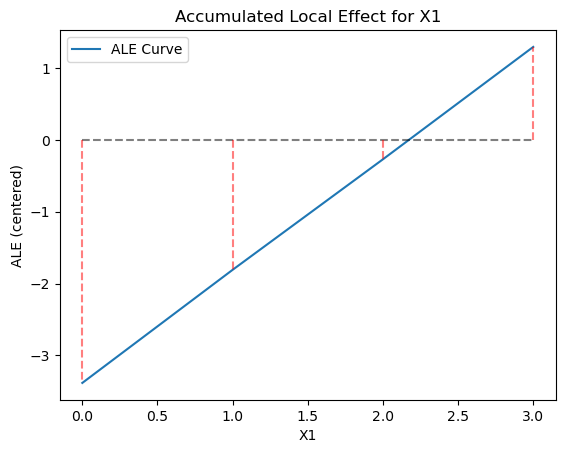

In [ ]:
edges1, curve1 = ale_1d(f, X, 1, bins, categorical=True)
x_vals = np.linspace(edges1.min(), edges1.max(), 100)
# theory = rho / 2 * x_vals ** 2 + x_vals - rho / 2
plt.figure()
plt.plot(edges1, curve1, label='ALE Curve')
# plt.plot(x_vals, theory, color='green', linestyle='--', label='Theoretical')
# draw horizontal line at y=0
plt.hlines(y=0, xmin=edges1.min(), xmax=edges1.max(), color='black', linestyle='--', alpha=0.5)
# draw vertical lines from 0 to the value of curve1 at each edge
plt.vlines(x=edges1, ymin=0, ymax=curve1, color='red', linestyle='--', alpha=0.5)
plt.xlabel("X1")
plt.ylabel("ALE (centered)")
plt.title("Accumulated Local Effect for X1")
plt.legend()
plt.show()

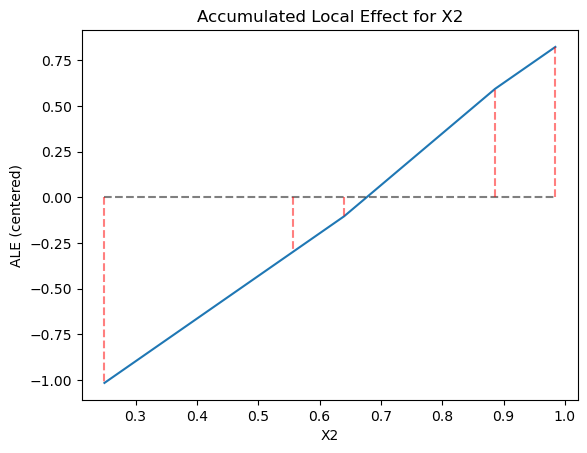

In [ ]:
edges2, curve2 = ale_1d(f, X, 2, bins=bins)
x_vals = np.linspace(edges2.min(), edges2.max(), 100)
# theory = rho / 2 * x_vals ** 2 + x_vals - rho / 2
plt.plot(edges2, curve2, label='ALE Curve')
# plt.plot(x_vals, theory, color='green', linestyle='--', label='Theoretical')
# draw horizontal line at y=0
plt.hlines(y=0, xmin=edges2.min(), xmax=edges2.max(), color='black', linestyle='--', alpha=0.5)
# draw vertical lines from 0 to the value of curve2 at each edge
plt.vlines(x=edges2, ymin=0, ymax=curve2, color='red', linestyle='--', alpha=0.5)
plt.xlabel("X2")
plt.ylabel("ALE (centered)")
plt.title("Accumulated Local Effect for X2")
plt.show()

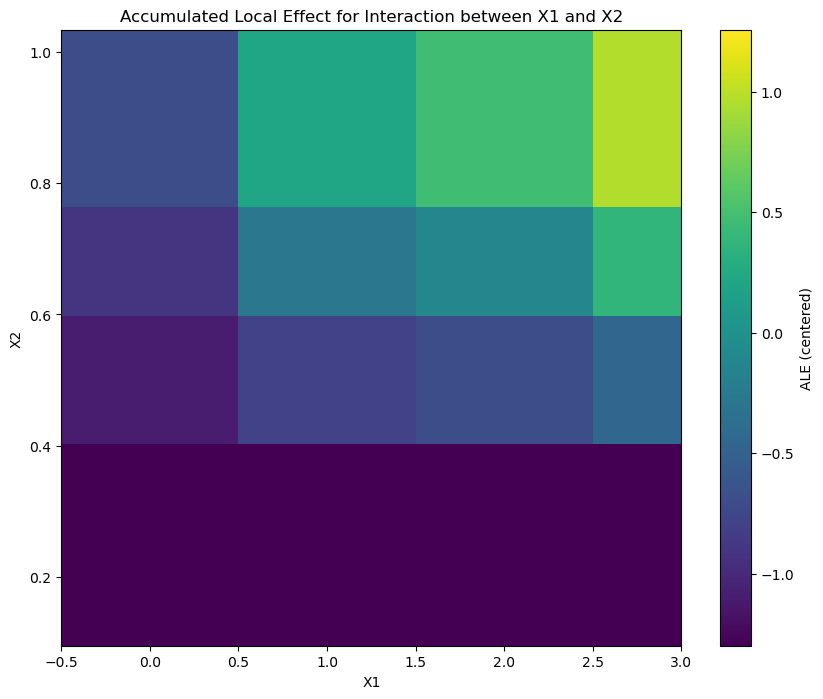

In [ ]:
edges1_interaction, edges2_interaction, curve_interaction = ale_2d(f, X, 1, 2, bins=bins)
edges1_mesh, edges2_mesh = np.meshgrid(edges1_interaction, edges2_interaction)
plt.figure(figsize=(10, 8))
# plot heatmap
plt.pcolormesh(edges1_mesh, edges2_mesh, curve_interaction, shading='auto', cmap='viridis')
plt.colorbar(label='ALE (centered)')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Accumulated Local Effect for Interaction between X1 and X2")
plt.show()